In [1]:
import awkward as ak
import numpy as np
import time
import coffea
import uproot
import hist
import vector
import json
print("awkward version ", ak.__version__)
print("coffea version ", coffea.__version__)
from coffea import util, processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema, BaseSchema
from collections import defaultdict
import pickle
import glob
import matplotlib.pyplot as plt

awkward version  1.10.3
coffea version  0.7.21


In [2]:
fileset = {"2016":[]} #, "2016APV":[]}

with open('data/nanoAOD/JetHT.json') as json_file:
    data = json.load(json_file)
    fileset['2016'] += ['root://cmsxrootd//'+data['2016']['F'][i] for i in range(len(data))]
    # fileset['2016APV'] += ['root://cmsxrootd//'+data['2016APV']['B'][i] for i in range(len(data))]
    # fileset['2016APV'] += ['root://cmsxrootd//'+data['2016APV']['C'][i] for i in range(len(data))]
print(fileset)

{'2016': ['root://cmsxrootd///store/data/Run2016F/JetHT/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/70000/4CF30F76-B083-4946-9F06-053FE8395464.root', 'root://cmsxrootd///store/data/Run2016F/JetHT/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/70000/D2CF1FA9-3B91-804A-B627-3A53CBB11404.root', 'root://cmsxrootd///store/data/Run2016F/JetHT/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/70000/D71F5FF4-F277-694A-8663-ED564A617323.root', 'root://cmsxrootd///store/data/Run2016F/JetHT/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/70000/F77A6FC2-0D11-6445-880B-5B8509DC4AB2.root', 'root://cmsxrootd///store/data/Run2016F/JetHT/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/70000/F901FFB3-64AA-A349-A162-36D029C626DC.root']}


In [4]:
class GetHT(processor.ProcessorABC):
    def __init__(self ):
    
        HT_axis = hist.axis.Regular( 50, 950, 1450, name="HT", label=r"AK4 Jet $H_T$")
        HTfull_axis = hist.axis.Regular( 41, 950, 3000, name="HT", label=r"AK4 Jet $H_T$")
        dataset_axis = hist.axis.StrCategory([], growth=True, name="dataset", label="Primary dataset")
        
        self.hists = {
            "ht":hist.Hist(dataset_axis, HT_axis, storage="weight", label="Counts"),
            "htfull":hist.Hist(dataset_axis, HTfull_axis, storage="weight", label="Counts")
        }
        
        self.means_stddevs = defaultdict()
    
    @property
    def accumulator(self):
        return self.hists

    
    # we will receive a NanoEvents instead of a coffea DataFrame
    def process(self, events):
        dataset = events.metadata['dataset']
        
        jetHT = ak.sum( events["Jet"].pt, axis=1 )
        # print(jetHT[jetHT>950.])
        
        self.hists['ht'].fill( dataset=dataset, HT=jetHT )
        self.hists['htfull'].fill( dataset=dataset, HT=jetHT )
        
        return self.hists

    
    def postprocess(self, accumulator):
        return accumulator
    
    
    

In [5]:
run = processor.Runner(
    executor = processor.FuturesExecutor(compression=None, workers=2),
    schema=NanoAODSchema,
    chunksize=100000,
    maxchunks=None
)

output = run(
    fileset,
    "Events",
    processor_instance=GetHT(),
)

Output()

Output()

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f14c92d90a0>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

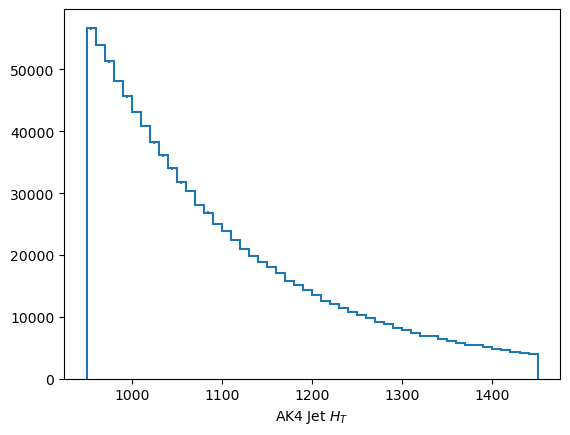

In [6]:
output['ht'].project("HT").plot()

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f147959e0a0>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

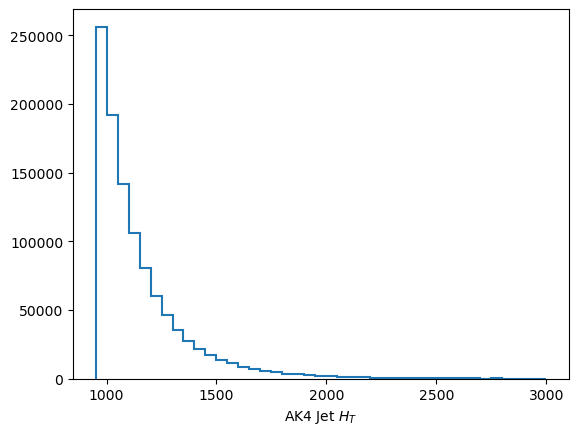

In [7]:
output['htfull'].project("HT").plot()

In [8]:
# HThist = output['ht']
# HThist.axes['HT'].edges

HThist = output['htfull']
HThist.axes['HT'].edges

array([ 950., 1000., 1050., 1100., 1150., 1200., 1250., 1300., 1350.,
       1400., 1450., 1500., 1550., 1600., 1650., 1700., 1750., 1800.,
       1850., 1900., 1950., 2000., 2050., 2100., 2150., 2200., 2250.,
       2300., 2350., 2400., 2450., 2500., 2550., 2600., 2650., 2700.,
       2750., 2800., 2850., 2900., 2950., 3000.])

In [9]:
# print('HT = ', HThist.axes['HT'].edges[0], '\tCounts = ', HThist.values()[0][0])
# print('HT = ', HThist.axes['HT'].edges[45], '\tCounts = ', HThist.values()[0][45])
# print('ratio = ', HThist.values()[0][45]/HThist.values()[0][0])

print('HT = ', HThist.axes['HT'].edges[0], '\tCounts = ', HThist.values()[0][0])
print('HT = ', HThist.axes['HT'].edges[9], '\tCounts = ', HThist.values()[0][9])
print('ratio = ', HThist.values()[0][9]/HThist.values()[0][0])

HT =  950.0 	Counts =  255658.0
HT =  1400.0 	Counts =  21926.0
ratio =  0.08576301152320678


In [10]:
# print('HT > ', HThist.axes['HT'].edges[0], '\tCounts = ', np.sum(HThist.values()[0][0:]))
# print('HT > ', HThist.axes['HT'].edges[45], '\tCounts = ', np.sum(HThist.values()[0][45:]))
# print('ratio = ', np.sum(HThist.values()[0][45:])/np.sum(HThist.values()[0][0:]))

print('HT > ', HThist.axes['HT'].edges[0], '\tCounts = ', np.sum(HThist.values()[0][0:]))
print('HT > ', HThist.axes['HT'].edges[9], '\tCounts = ', np.sum(HThist.values()[0][9:]))
print('ratio = ', np.sum(HThist.values()[0][9:])/np.sum(HThist.values()[0][0:]))

HT >  950.0 	Counts =  1059174.0
HT >  1400.0 	Counts =  112564.0
ratio =  0.10627526733095789
